In [ ]:
#########################################################################
# # ! Moon Topographic-Gravitational-Potential Computation: PH vs SH
#########################################################################
# %% 
# # ! Setup
import numpy as np
import pandas as pd
import pyshtools as pysh
import pygmt
import xarray as xr
from datetime import datetime
from gravity_forward_numba import *

In [ ]:
# # ! Start time
print("=" * 80)
print(f"Start time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

Start time: [2026-05-19 20:59:22]


In [ ]:
# # ! Load Topo data
#### * Topography
lmax_shp = 359
in_res = 15.0/60.0 # degree
nc_file_Topo = f'output/moon_topo_Lshp{lmax_shp}_{int(60*in_res)}arcmin.nc'
data_Topo = xr.open_dataset(nc_file_Topo)
grd_topo_moon = data_Topo['topo'].data

In [ ]:
# # ! Load TGP data: SH vs PH
#### * SH
max_nmax = 7
nc_file_SH = f'output/moon_topo_gravity_Lshp{lmax_shp}_nmax{max_nmax}.nc'
data_SH = xr.open_dataset(nc_file_SH)
gn_SH = data_SH['gx'].data[::max_nmax, ::max_nmax]
ge_SH = data_SH['gy'].data[::max_nmax, ::max_nmax]
gd_SH = data_SH['gz'].data[::max_nmax, ::max_nmax]
#### * PH
out_res = 15.0/60.0 # degree
nc_file_PH = (f"output/moon_topo_gravity_in{int(in_res*60)}arcmin"
              f"_out{int(out_res*60)}arcmin.nc")
data_PH = xr.open_dataset(nc_file_PH)
gn_PH = data_PH['gN'].data
ge_PH = data_PH['gE'].data
gd_PH = data_PH['gD'].data
#### * Diff = PH - SH
d_gn, d_ge, d_gd = gn_PH - gn_SH, ge_PH - ge_SH, gd_PH - gd_SH
d_gn[[0, -1], :] = 0.0
d_ge[[0, -1], :] = 0.0
#### * Summary statistics
g_SH = {'N': gn_SH, 'E': ge_SH, 'D': gd_SH}
g_PH = {'N': gn_PH, 'E': ge_PH, 'D': gd_PH}
d_g  = {'N': d_gn,  'E': d_ge,  'D': d_gd}
print('-' * 80)
print('Gravity Vector components in mGal')
print(f"{'Type':4s} | {'Comp':4s} | {'min':>9s} | {'max':>9s} | {'mean':>9s} | {'std':>9s}")
print('-' * 80)
datasets = {'SH': g_SH, 'PH': g_PH, 'Diff': d_g}
for typ in ['SH', 'PH', 'Diff']:
    for comp in ['N', 'E', 'D']:
        data = datasets[typ][comp]
        print(f"{typ:4s} | {f'g{comp}':4s} | {data.min():9.4f} | {data.max():9.4f} | "
              f"{data.mean():9.4f} | {data.std():9.4f}")
    print('=' * 60)

--------------------------------------------------------------------------------
Gravity Vector components in mGal
Type | Comp |       min |       max |      mean |       std
--------------------------------------------------------------------------------
SH   | gN   | -488.8082 |  933.4147 |   10.3820 |  154.3514
SH   | gE   | -551.9941 |  606.5575 |    0.0197 |  150.2317
SH   | gD   | -721.8590 | 1189.4579 |  -35.0952 |  246.4136
PH   | gN   | -486.9639 |  926.2217 |   10.3856 |  154.2915
PH   | gE   | -548.6204 |  605.3110 |    0.0197 |  150.2471
PH   | gD   | -721.7818 | 1182.6341 |  -36.0165 |  246.2114
Diff | gN   |  -12.0679 |   12.5141 |    0.0033 |    0.8889
Diff | gE   |  -11.6858 |   10.1128 |   -0.0000 |    0.7200
Diff | gD   |  -21.5349 |   12.9305 |   -0.9213 |    1.1324


In [ ]:
# # ! Top-N largest |gD| errors (PH - SH) with >1000 km separation
n_largest = 10
min_dist_km = 1000.0
R_moon = 1737.4  # km
abs_err = np.abs(d_gd).flatten()
idx_sorted = np.argsort(-abs_err)
lats_1d = data_PH['latitude'].data
lons_1d = data_PH['longitude'].data
nlat, nlon = d_gd.shape
pk_flat_idx = []
for idx in idx_sorted:
    if len(pk_flat_idx) >= n_largest:
        break
    i_lat, j_lon = np.unravel_index(idx, (nlat, nlon))
    lat_new, lon_new = np.radians([lats_1d[i_lat], lons_1d[j_lon]])
    keep = True
    for idx_sel in pk_flat_idx:
        ii, jj = np.unravel_index(idx_sel, (nlat, nlon))
        lat_old, lon_old = np.radians([lats_1d[ii], lons_1d[jj]])
        dlat = lat_new - lat_old
        dlon = lon_new - lon_old
        # Haversine formula
        a = np.sin(dlat/2)**2 + np.cos(lat_new)*np.cos(lat_old)*np.sin(dlon/2)**2
        dist_km = R_moon * 2 * np.arcsin(np.sqrt(a))
        if dist_km < min_dist_km:
            keep = False
            break
    if keep:
        pk_flat_idx.append(idx)
lat_indices, lon_indices = np.unravel_index(pk_flat_idx, (nlat, nlon))
print("=" * 104)
print(f"Top {n_largest} largest |gD| errors (PH - SH), >{min_dist_km} km apart")
print("=" * 104)
print(f"{'Rank':>4} | {'Lat (°)':>8} | {'Lon (°)':>8} | {'Topo (m)':>9} | "
      f"{'gD_SH':>10} | {'gD_PH':>10} | {'Error':>9} | {'|Error|':>9}")
print("-" * 104)
records = []
for idx in range(len(pk_flat_idx)):
    i_lat, j_lon = lat_indices[idx], lon_indices[idx]
    topo_m = grd_topo_moon[i_lat, j_lon] * 1e3
    gd_sh_val = gd_SH[i_lat, j_lon]
    gd_ph_val = gd_PH[i_lat, j_lon]
    err = d_gd[i_lat, j_lon]
    abs_err = abs(err)
    print(f"{idx+1:4d} | {lats_1d[i_lat]:8.3f} | {lons_1d[j_lon]:8.3f} | {topo_m:9.1f} | "
          f"{gd_sh_val:10.4f} | {gd_ph_val:10.4f} | {err:9.4f} | {abs_err:9.4f}")
    records.append({
        "Rank": idx + 1,
        "Lat_deg": lats_1d[i_lat],
        "Lon_deg": lons_1d[j_lon],
        "Topo_m": topo_m,
        "gD_SH": gd_sh_val,
        "gD_PH": gd_ph_val,
        "Error": err,
        "AbsErr": abs_err
    })
print("=" * 104)
df_errors = pd.DataFrame(records)
df_errors.to_csv("Moon_gD_errors.csv", index=False, float_format="%.4f")
print(f"\nTable data saved to: Moon_gD_errors.csv")

Top 10 largest |gD| errors (PH - SH), >1000.0 km apart
Rank |  Lat (°) |  Lon (°) |  Topo (m) |      gD_SH |      gD_PH |     Error |   |Error|
--------------------------------------------------------------------------------------------------------
   1 |  -22.500 |  204.000 |    8551.1 |   694.1629 |   672.6280 |  -21.5349 |   21.5349
   2 |   -7.500 |  142.000 |    7378.5 |   670.9713 |   654.8978 |  -16.0735 |   16.0735
   3 |   15.500 |  227.750 |    8002.7 |   835.4962 |   822.7385 |  -12.7577 |   12.7577
   4 |  -49.000 |  128.250 |    5615.6 |   316.5163 |   304.4645 |  -12.0518 |   12.0518
   5 |    8.500 |  191.750 |    6548.9 |   715.7953 |   703.8809 |  -11.9144 |   11.9144
   6 |   -8.000 |  255.250 |    6711.6 |   645.0012 |   634.2254 |  -10.7757 |   10.7757
   7 |  -50.250 |  237.000 |    4953.5 |   201.4811 |   191.7000 |   -9.7812 |    9.7812
   8 |  -65.750 |    0.750 |    5050.3 |   251.6558 |   242.8693 |   -8.7865 |    8.7865
   9 |   23.250 |    1.750 |    3179.1 

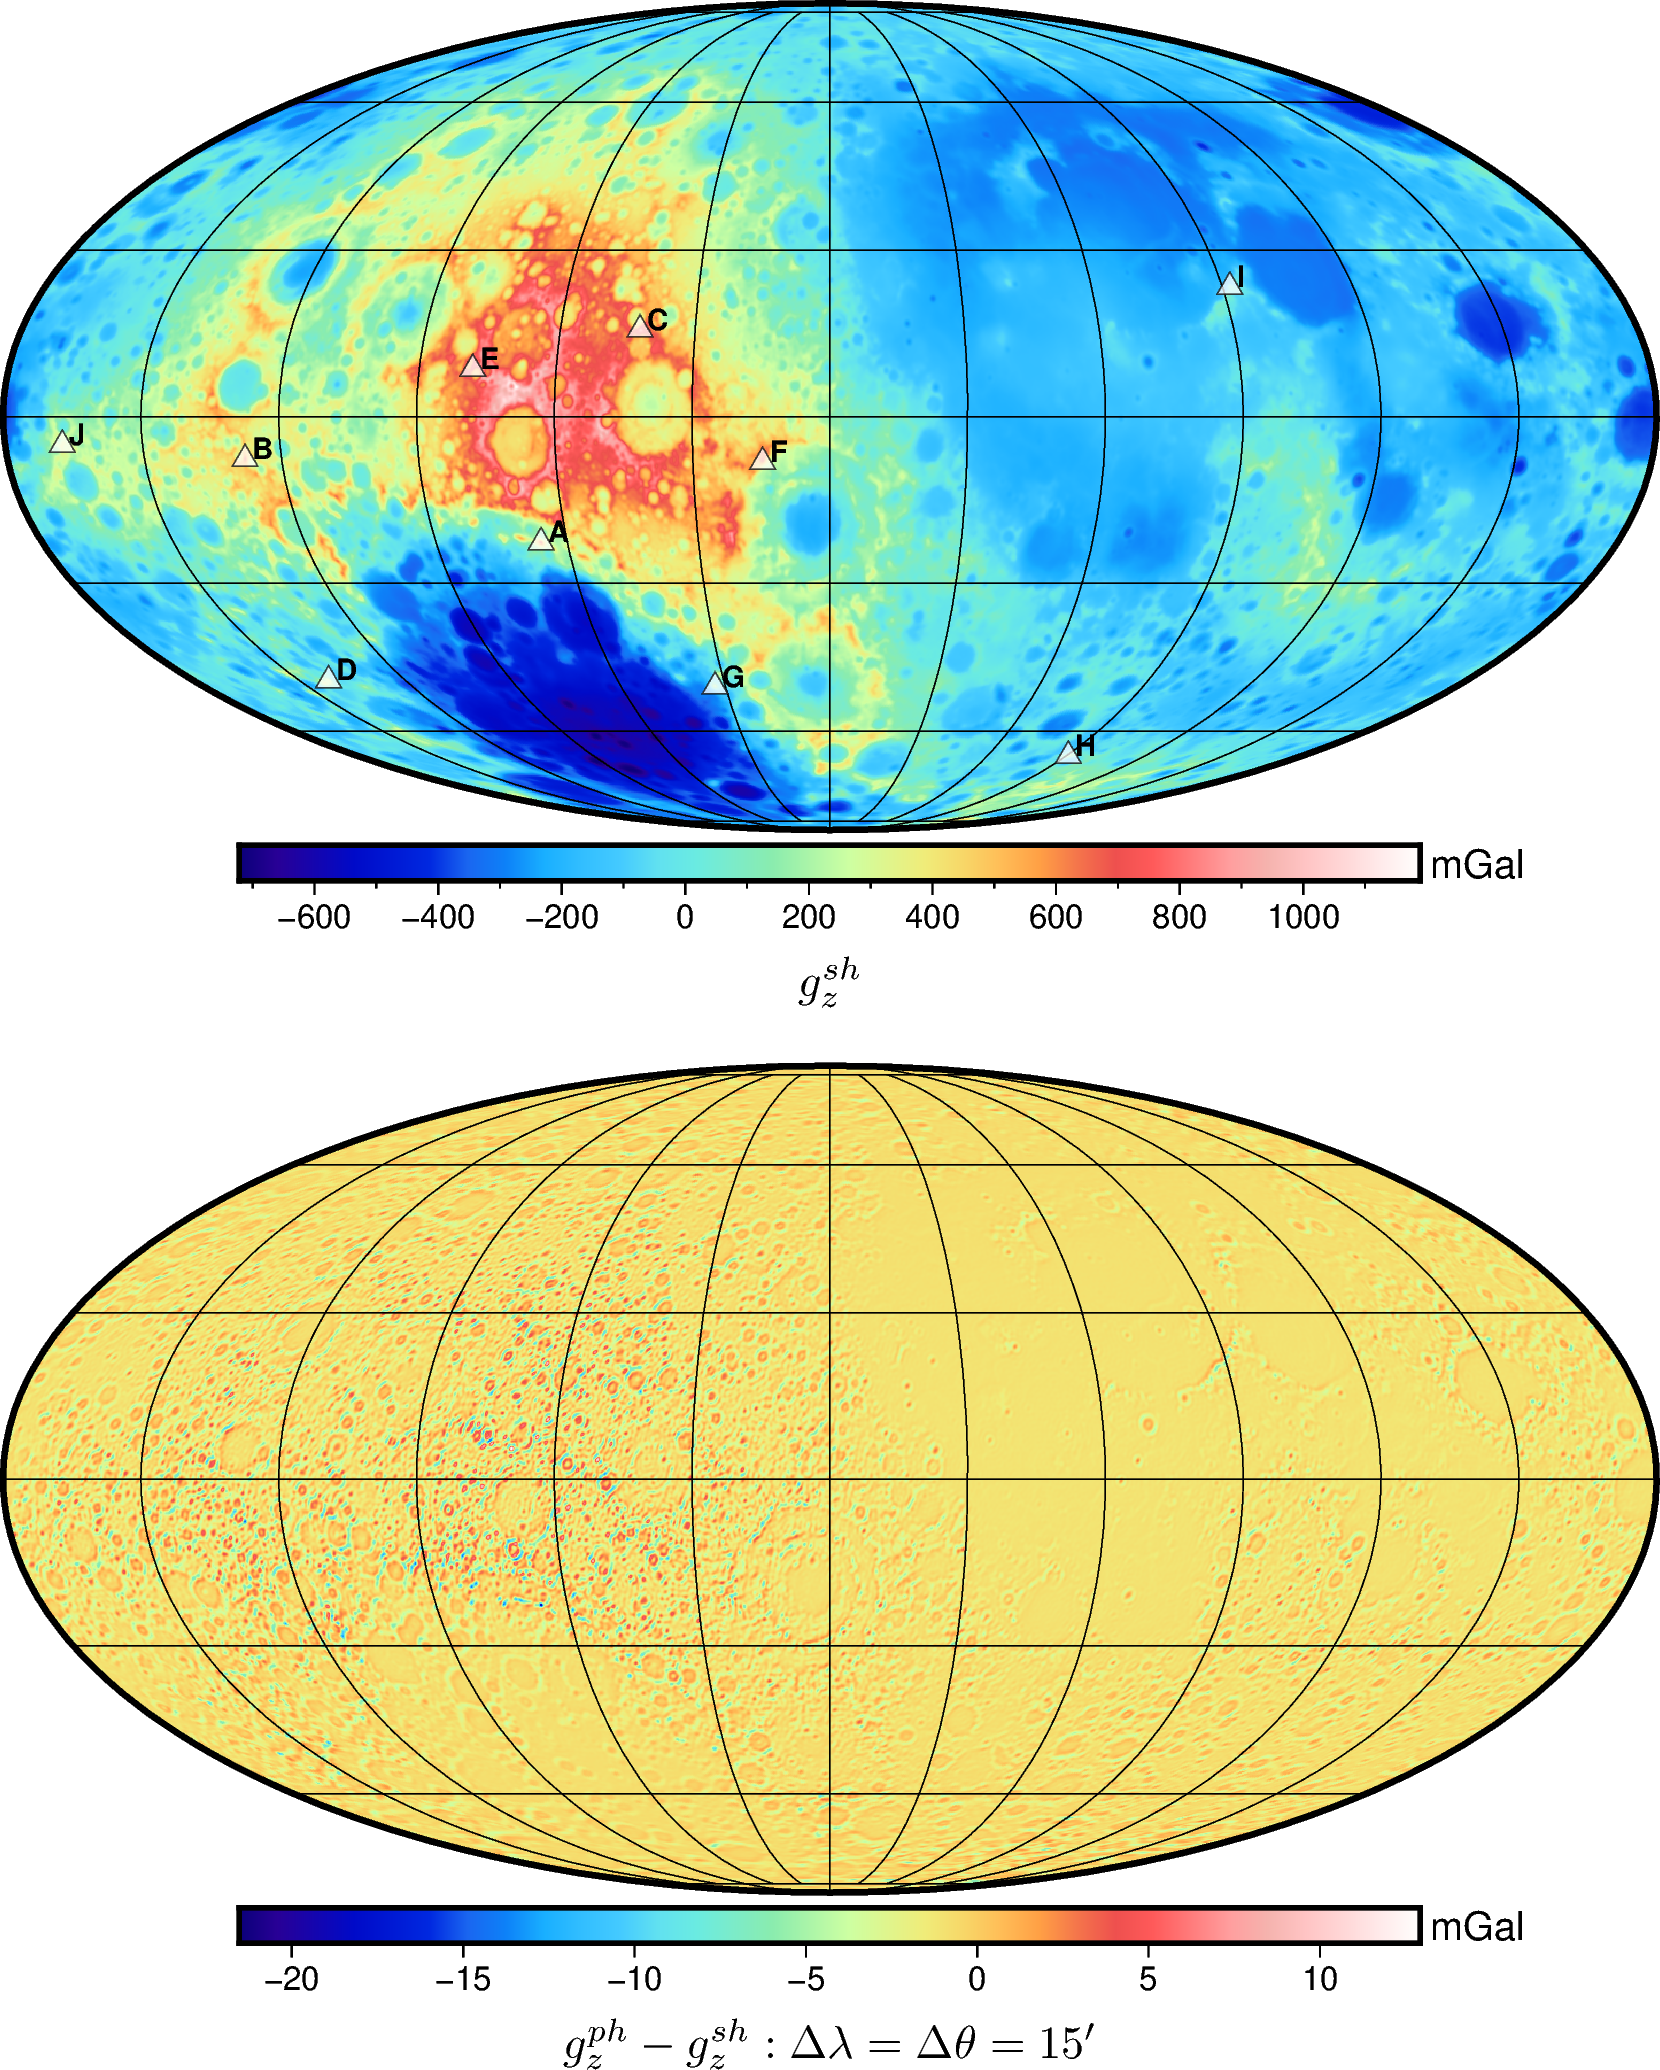

In [ ]:
# # ! Mapping: SH vs PH
err_txt = ['A','B','C','D','E','F','G','H','I','J']
xr_gd_SH = pysh.SHGrid.from_array(gd_SH).to_xarray()
xr_d_gd = pysh.SHGrid.from_array(d_gd).to_xarray()
fig = pygmt.Figure()
with fig.subplot(nrows=2, ncols=1, figsize=('14c', '16.5c'), margins="0.5c"):
    with fig.set_panel(panel=0): 
        fig.grdimage(grid=xr_gd_SH, projection="W-90/14c", 
                     cmap="haxby", frame="g30")
        fig.plot(x=lons_1d[lon_indices], y=lats_1d[lat_indices], 
                 projection="W-90/14c", transparency=25,
                 style="t0.25c", fill="white", pen="0.25p,black")
        fig.text(x=lons_1d[lon_indices], y=lats_1d[lat_indices], text=err_txt, 
                 projection="W-90/14c", justify="BL", 
                 offset="0.06c/0.0c", font="7p,Helvetica-Bold,black")
        fig.colorbar(position="JBC+o0/0.15i+w10c/0.3h", 
                     frame=["a200f100", "x+l@[ g_z^{sh} @[", "y+lmGal"])    
    with fig.set_panel(panel=1): 
        fig.grdimage(grid=xr_d_gd, projection="W-90/14c", 
                     cmap="haxby", frame="g30")
        xlabel = r"@[ g_z^{ph}-g_z^{sh}: \Delta \lambda = \Delta \theta = 15^{\prime}@["
        fig.colorbar(position="JBC+o0/0.15i+w10c/0.3h", 
                     frame=["a5f5", f"x+l{xlabel}", "y+lmGal"])    
# fig.savefig('Moon_TopoGz_PH_vs_SH_1.png', dpi=400)
fig.show(width=800)

In [ ]:
# # ! End time
print("=" * 80)
print(f"End time: [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}]")
print("=" * 80)

End time: [2026-05-19 20:59:25]
